# Application laboratory: a linear-chain conditional random field for text

A linear-chain conditional random field (CRF) assigns a structured label sequence $y_{1:T}$ to an observed token sequence $x_{1:T}$:

$$
P(y_{1:T}\mid x_{1:T})\propto \prod_{t=1}^T \psi_t(y_t;x)\prod_{t=1}^{T-1}\psi_{t,t+1}(y_t,y_{t+1};x).
$$

Because the label graph is a chain, partition functions and marginals are computed exactly by forward--backward message passing, while the MAP sequence is found by Viterbi/min-sum. This classical structured-prediction model is a direct bridge from graphical models to modern learned sequence representations.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
tokens=['fluid','flow','becomes','strongly','turbulent','today']
labels=['N','V','A']  # noun, verb, adjective/adverb (toy categories)
T=len(tokens); K=len(labels)
# Hand-built unary log scores; rows=tokens, cols=labels
U=np.array([[2.2,.1,.2],[1.9,.6,.1],[.2,2.4,.1],[.1,.4,1.8],[.3,.2,2.5],[1.0,.4,.5]])
# transition preferences
A=np.array([[.5,.8,.1],[.4,.2,.9],[.7,.3,.2]])
# forward/backward in exp-score domain with normalization
alpha=np.zeros((T,K)); alpha[0]=np.exp(U[0]); alpha[0]/=alpha[0].sum()
scales=[1]
for t in range(1,T):
    alpha[t]=np.exp(U[t])*(alpha[t-1]@np.exp(A)); alpha[t]/=alpha[t].sum()
beta=np.ones((T,K))
for t in range(T-2,-1,-1):
    beta[t]=np.exp(A)@(np.exp(U[t+1])*beta[t+1]); beta[t]/=beta[t].sum()
marg=alpha*beta; marg/=marg.sum(axis=1,keepdims=True)
# Viterbi
D=np.zeros((T,K)); back=np.zeros((T,K),int); D[0]=U[0]
for t in range(1,T):
    scores=D[t-1][:,None]+A; back[t]=scores.argmax(axis=0); D[t]=U[t]+scores.max(axis=0)
y=np.zeros(T,int); y[-1]=D[-1].argmax()
for t in range(T-2,-1,-1): y[t]=back[t+1,y[t+1]]
ind=U.argmax(axis=1)
print('independent labels:',[labels[k] for k in ind]); print('CRF MAP labels:',[labels[k] for k in y])

independent labels: ['N', 'N', 'V', 'A', 'A', 'N']
CRF MAP labels: ['N', 'N', 'V', 'A', 'A', 'N']


/tmp/ipykernel_2283/1440664098.py:38: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)


Saved ch11_07_crf_factor_graph


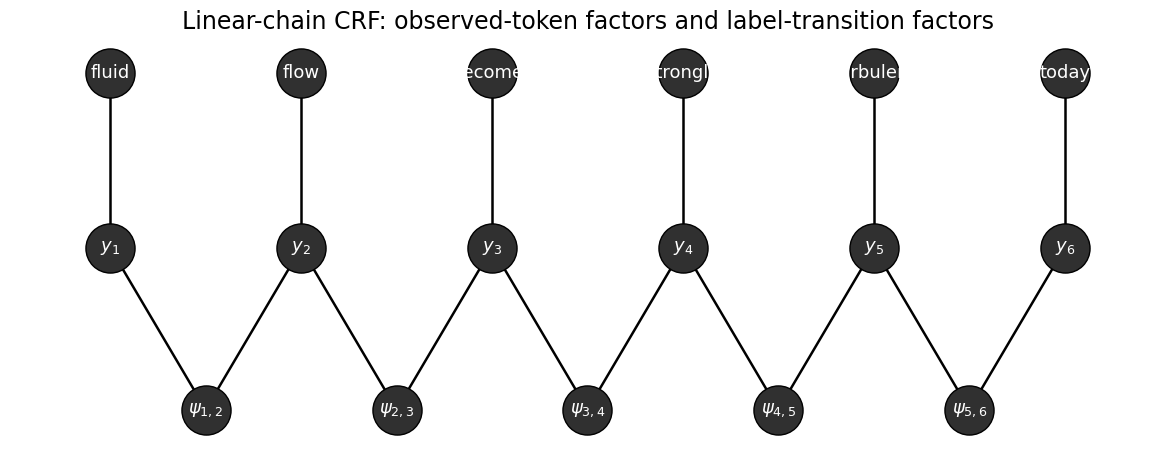

Saved ch11_07_crf_marginals


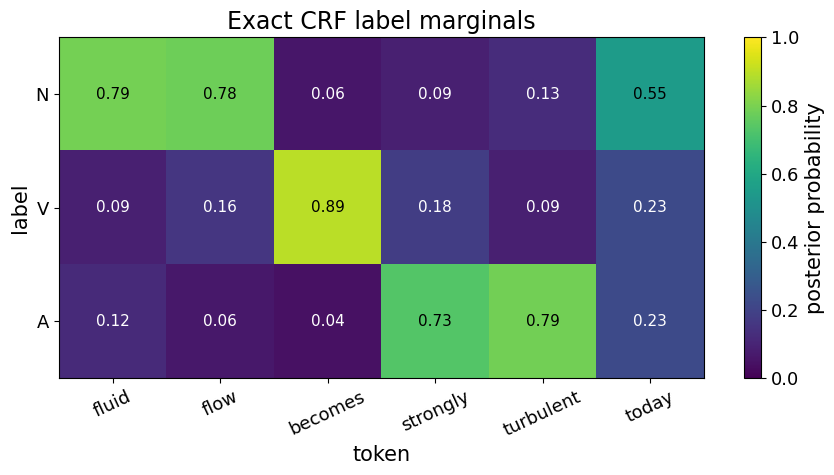

In [3]:
# chain factor graph
G=nx.Graph(); pos={}; labs={}
for t,tok in enumerate(tokens):
    vn=f'y{t+1}'; un=f'u{t+1}'; G.add_edge(vn,un); pos[vn]=(2*t,0); pos[un]=(2*t,1.3); labs[vn]=rf'$y_{t+1}$'; labs[un]=tok
    if t<T-1:
        pn=f'p{t+1}'; G.add_edge(vn,pn); G.add_edge(pn,f'y{t+2}'); pos[pn]=(2*t+1,-1.2); labs[pn]=rf'$\psi_{{{t+1},{t+2}}}$'
fig,ax=plt.subplots(figsize=(12,4.8)); draw_dark_nodes(G,pos,labels=labs,ax=ax,node_size=1250); ax.set_title('Linear-chain CRF: observed-token factors and label-transition factors'); ax.axis('off'); fig.tight_layout(); save_figure(fig,'ch11_07_crf_factor_graph'); plt.show()

fig,ax=plt.subplots(figsize=(9,5)); im=ax.imshow(marg.T,vmin=0,vmax=1,aspect='auto'); ax.set_xticks(range(T),tokens,rotation=25); ax.set_yticks(range(K),labels); ax.set_xlabel('token'); ax.set_ylabel('label'); ax.set_title('Exact CRF label marginals'); annotate_heatmap(ax,im,marg.T); fig.colorbar(im,ax=ax,label='posterior probability'); fig.tight_layout(); save_figure(fig,'ch11_07_crf_marginals'); plt.show()

## Exercises

1. Remove the pairwise transition factors. Verify that the CRF reduces to independent token classification.
2. Increase one transition score strongly enough to change the MAP sequence even when no unary argmax changes. Explain this as collective inference.
3. Replace the hand-built unary scores by outputs of a small neural network. Which part of the graphical-model semantics remains exact?
4. Compare a CRF decoder with an autoregressive decoder. Identify the direction of conditioning and the role of the partition function in each.